<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-7/blob/main/Ejercicio3_clustering_circles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering sobre el dataset sintetico `circles`

**Objetivo:** entrenar tres algoritmos de clustering (K-means, DBSCAN y SpectralClustering) sobre el dataset sintetico de dos circulos concentricos y evaluarlos con metricas de validacion **externa** (comparan contra las etiquetas reales) e **interna** (solo usan los datos y las etiquetas de cluster).

Contenido:
1. Generacion y visualizacion del dataset
2. Ajuste de hiperparametros (K-means y DBSCAN)
3. Entrenamiento de los tres modelos
4. Visualizacion de resultados
5. Metricas de validacion externa e interna
6. Analisis e interpretacion

## 0. Librerias

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 110

## 1. Dataset sintetico `circles`

Se generan 1000 puntos distribuidos en dos circulos concentricos (`factor=0.5` es la razon entre el radio interno y el externo, y `noise=0.05` agrega ruido gaussiano).

- `y_true` contiene las etiquetas reales (0 = circulo externo, 1 = circulo interno). **No se usan para entrenar**, solo para la validacion externa.
- Siguiendo las buenas practicas vistas en clase, las caracteristicas se **estandarizan** con `StandardScaler` antes de agrupar.

In [12]:
X_raw, y_true = make_circles(
    n_samples=1000,
    factor=0.5,
    noise=0.05,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Forma de X:", X.shape)
print("Clases reales:", np.unique(y_true), "| muestras por clase:", np.bincount(y_true))

Forma de X: (1000, 2)
Clases reales: [0 1] | muestras por clase: [500 500]


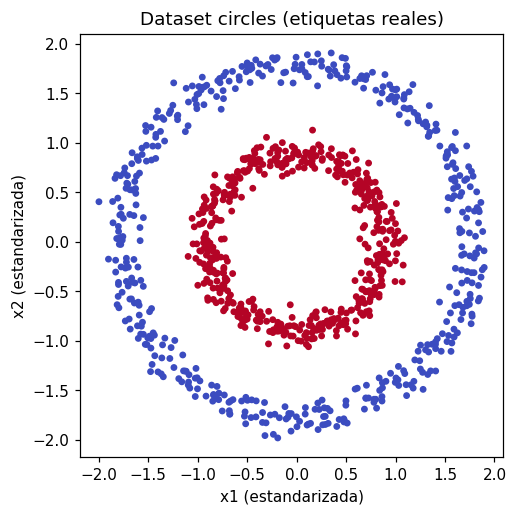

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap="coolwarm", s=12)
ax.set_title("Dataset circles (etiquetas reales)")
ax.set_xlabel("x1 (estandarizada)")
ax.set_ylabel("x2 (estandarizada)")
ax.set_aspect("equal")
plt.show()

## 2. Ajuste de hiperparametros

### 2.1 K-means: metodo del codo y silueta

K-means requiere indicar el numero de clusters `k`. Se calcula la suma de cuadrados dentro de los clusters (WSS o inercia) y la silueta media para distintos valores de `k`.

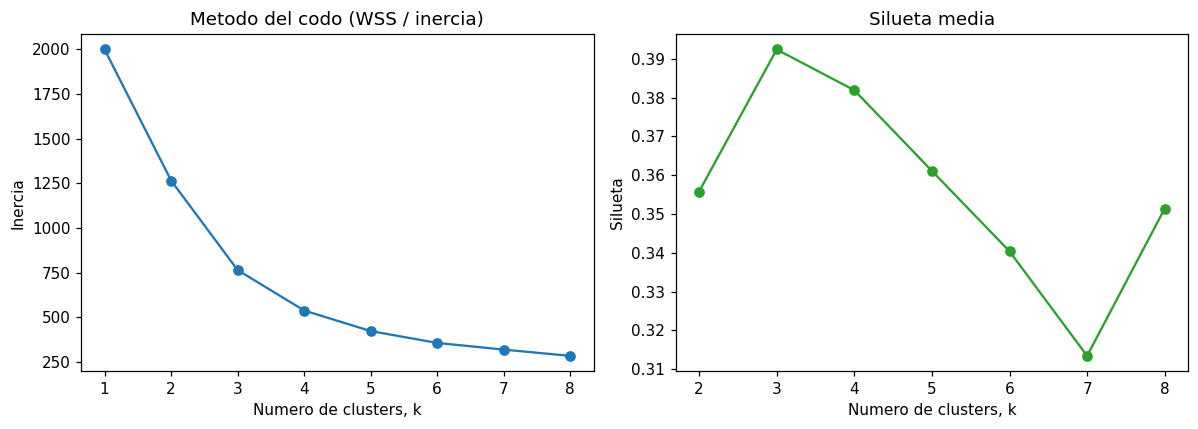

In [14]:
ks = range(1, 9)
wss = []
sil = []

for k in ks:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    wss.append(modelo.inertia_)
    if k >= 2:
        sil.append(metrics.silhouette_score(X, modelo.labels_))
    else:
        sil.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(ks), wss, marker="o")
axes[0].set_title("Metodo del codo (WSS / inercia)")
axes[0].set_xlabel("Numero de clusters, k")
axes[0].set_ylabel("Inercia")

axes[1].plot(list(ks), sil, marker="o", color="tab:green")
axes[1].set_title("Silueta media")
axes[1].set_xlabel("Numero de clusters, k")
axes[1].set_ylabel("Silueta")

plt.tight_layout()
plt.show()

Sabemos por construccion que existen **2 grupos reales**, por lo que se usa `k = 2` para K-means. Esto permite compararlo en igualdad de condiciones con SpectralClustering, que tambien necesita el numero de grupos.

### 2.2 DBSCAN: eleccion de `eps` con el grafico de k-distancias

DBSCAN no requiere el numero de clusters, pero si `eps` (radio de vecindad) y `min_samples`. Una heuristica habitual es graficar la distancia de cada punto a su `min_samples`-esimo vecino mas cercano, ordenada de menor a mayor, y elegir `eps` cerca del punto donde la curva empieza a crecer con rapidez.

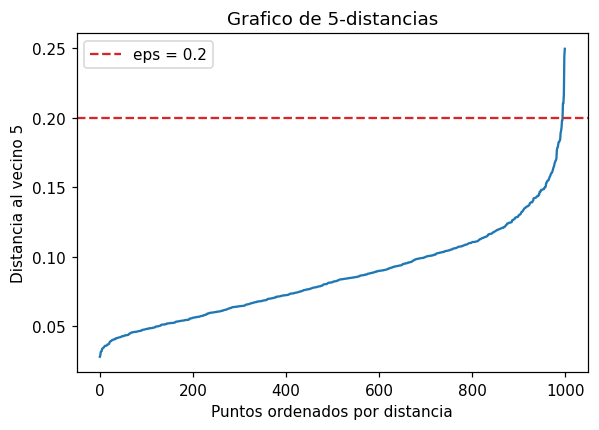

In [15]:
MIN_SAMPLES = 5

vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distancias, _ = vecinos.kneighbors(X)
k_dist = np.sort(distancias[:, -1])

EPS = 0.2

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_dist)
ax.axhline(EPS, color="tab:red", linestyle="--", label=f"eps = {EPS}")
ax.set_title(f"Grafico de {MIN_SAMPLES}-distancias")
ax.set_xlabel("Puntos ordenados por distancia")
ax.set_ylabel(f"Distancia al vecino {MIN_SAMPLES}")
ax.legend()
plt.show()

## 3. Entrenamiento de los modelos

- **K-means:** `n_clusters=2`. Fronteras de decision lineales (regiones de Voronoi alrededor de los centroides).
- **DBSCAN:** `eps=0.2`, `min_samples=5`. Agrupa por densidad; puede dejar puntos como ruido (etiqueta `-1`).
- **SpectralClustering:** `n_clusters=2`, afinidad `nearest_neighbors`. Construye un grafo de vecinos y agrupa en el espacio espectral, lo que permite fronteras no lineales.

Nota sobre SpectralClustering: con los dos circulos bien separados, el grafo de vecinos queda con dos componentes conectados y scikit-learn emite una advertencia informativa. Es un comportamiento esperado en este dataset y no afecta el resultado, por eso se silencia esa advertencia puntual.

In [16]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
)

labels_kmeans = kmeans.fit_predict(X)
labels_dbscan = dbscan.fit_predict(X)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Graph is not fully connected")
    labels_spectral = spectral.fit_predict(X)

resultados = {
    "K-means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "SpectralClustering": labels_spectral,
}

for nombre, etiquetas in resultados.items():
    print(f"{nombre:<20} etiquetas unicas: {np.unique(etiquetas)}")

K-means              etiquetas unicas: [0 1]
DBSCAN               etiquetas unicas: [0 1]
SpectralClustering   etiquetas unicas: [0 1]


## 4. Visualizacion de los resultados

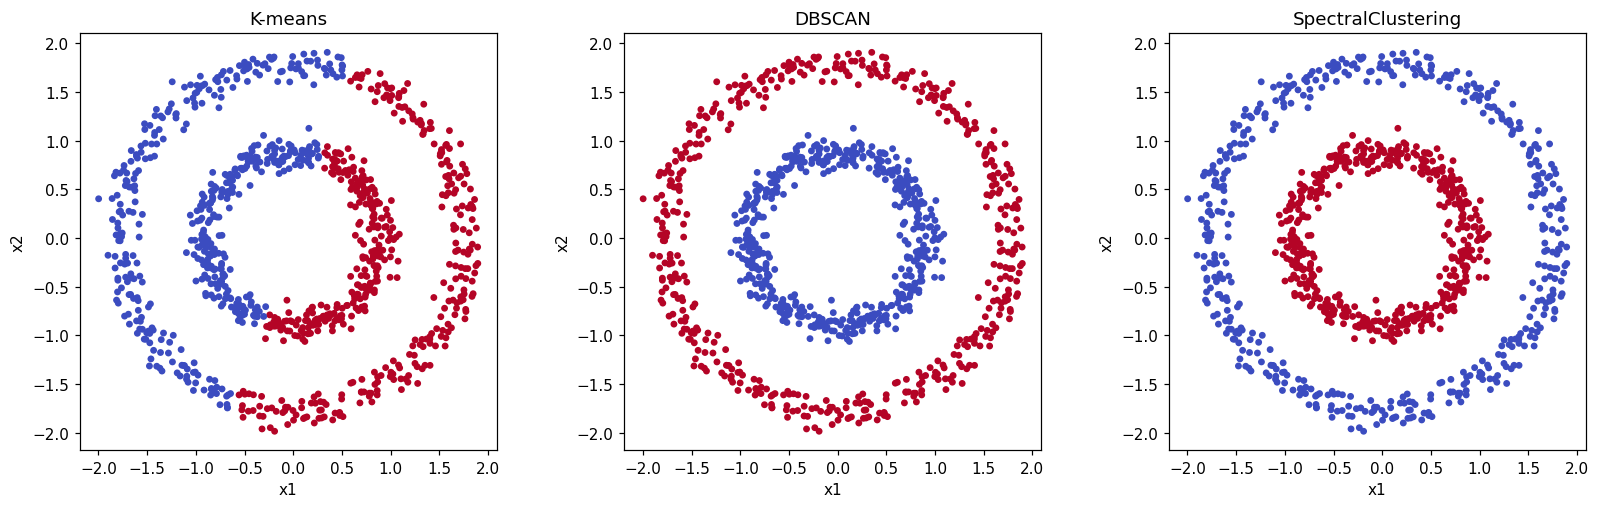

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, (nombre, etiquetas) in zip(axes, resultados.items()):
    ruido = etiquetas == -1
    ax.scatter(X[~ruido, 0], X[~ruido, 1], c=etiquetas[~ruido], cmap="coolwarm", s=12)
    if ruido.any():
        ax.scatter(X[ruido, 0], X[ruido, 1], c="black", s=25, marker="x", label="ruido")
        ax.legend()
    ax.set_title(nombre)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 5. Metricas de validacion

### 5.1 Validacion externa (requiere las etiquetas reales)

| Metrica | Que mide | Mejor valor |
|---|---|---|
| Adjusted Rand Index (ARI) | Coincidencia entre pares de puntos, corregida por azar | 1 |
| Adjusted Mutual Information (AMI) | Informacion mutua ajustada por azar | 1 |
| Normalized Mutual Information (NMI) | Informacion mutua normalizada | 1 |
| Homogeneidad | Cada cluster contiene puntos de una sola clase | 1 |
| Completitud | Todos los puntos de una clase quedan en el mismo cluster | 1 |
| V-measure | Media armonica de homogeneidad y completitud | 1 |
| Fowlkes-Mallows | Media geometrica de precision y recall por pares | 1 |
| Informacion mutua (MI) | Informacion compartida, en nats (maximo ln 2 = 0.693 con 2 clases balanceadas) | mayor es mejor |

### 5.2 Validacion interna (solo usa X y las etiquetas de cluster)

| Metrica | Que mide | Mejor valor |
|---|---|---|
| Silueta | Cohesion frente a separacion, entre -1 y 1 | cercano a 1 |
| Calinski-Harabasz | Razon entre dispersion entre clusters y dentro de clusters | mayor |
| Davies-Bouldin | Similitud promedio entre cada cluster y su mas parecido | menor |

**Tratamiento del ruido de DBSCAN:** en las metricas externas el ruido (`-1`) se considera un grupo mas. En las internas se excluyen los puntos de ruido, y solo se calculan si hay al menos 2 clusters.

Como referencia se incluye una fila con las **etiquetas reales**, para ver que puntaje interno obtiene el agrupamiento correcto.

In [18]:
def evaluar_clustering(nombre, X, y_true, etiquetas):
    """Devuelve un diccionario con metricas externas e internas."""
    mascara = etiquetas != -1
    n_clusters = len(np.unique(etiquetas[mascara]))

    fila = {
        "Modelo": nombre,
        "Clusters": n_clusters,
        "Ruido": int((~mascara).sum()),
        # Validacion externa
        "ARI": metrics.adjusted_rand_score(y_true, etiquetas),
        "AMI": metrics.adjusted_mutual_info_score(y_true, etiquetas),
        "NMI": metrics.normalized_mutual_info_score(y_true, etiquetas),
        "Homogeneidad": metrics.homogeneity_score(y_true, etiquetas),
        "Completitud": metrics.completeness_score(y_true, etiquetas),
        "V-measure": metrics.v_measure_score(y_true, etiquetas),
        "Fowlkes-Mallows": metrics.fowlkes_mallows_score(y_true, etiquetas),
        "Info. mutua": metrics.mutual_info_score(y_true, etiquetas),
    }

    # Validacion interna (sin puntos de ruido, minimo 2 clusters)
    if n_clusters >= 2 and mascara.sum() > n_clusters:
        Xm, lm = X[mascara], etiquetas[mascara]
        fila["Silueta"] = metrics.silhouette_score(Xm, lm)
        fila["Calinski-Harabasz"] = metrics.calinski_harabasz_score(Xm, lm)
        fila["Davies-Bouldin"] = metrics.davies_bouldin_score(Xm, lm)
    else:
        fila["Silueta"] = np.nan
        fila["Calinski-Harabasz"] = np.nan
        fila["Davies-Bouldin"] = np.nan

    return fila


filas = [evaluar_clustering(n, X, y_true, e) for n, e in resultados.items()]
filas.append(evaluar_clustering("Etiquetas reales (referencia)", X, y_true, y_true))

tabla = pd.DataFrame(filas).set_index("Modelo")

cols_externas = ["ARI", "AMI", "NMI", "Homogeneidad", "Completitud",
                 "V-measure", "Fowlkes-Mallows", "Info. mutua"]
cols_internas = ["Silueta", "Calinski-Harabasz", "Davies-Bouldin"]

In [19]:
print("VALIDACION EXTERNA")
display(tabla[["Clusters", "Ruido"] + cols_externas].round(4))

VALIDACION EXTERNA


,Clusters,Ruido,ARI,AMI,NMI,Homogeneidad,Completitud,V-measure,Fowlkes-Mallows,Info. mutua
Modelo,,,,,,,,,,
K-means,2,0,-0.001,-0.0007,0.0,0.0,0.0,0.0,0.499,0.0000
DBSCAN,2,0,1.000,1.0000,1.0,1.0,1.0,1.0,1.000,0.6931
SpectralClustering,2,0,1.000,1.0000,1.0,1.0,1.0,1.0,1.000,0.6931
Etiquetas reales (referencia),2,0,1.000,1.0000,1.0,1.0,1.0,1.0,1.000,0.6931


In [20]:
print("VALIDACION INTERNA")
display(tabla[cols_internas].round(4))

VALIDACION INTERNA


,Silueta,Calinski-Harabasz,Davies-Bouldin
Modelo,,,
K-means,0.3558,578.7181,1.1818
DBSCAN,0.1125,0.0011,892.1388
SpectralClustering,0.1125,0.0011,892.1388
Etiquetas reales (referencia),0.1125,0.0011,892.1388


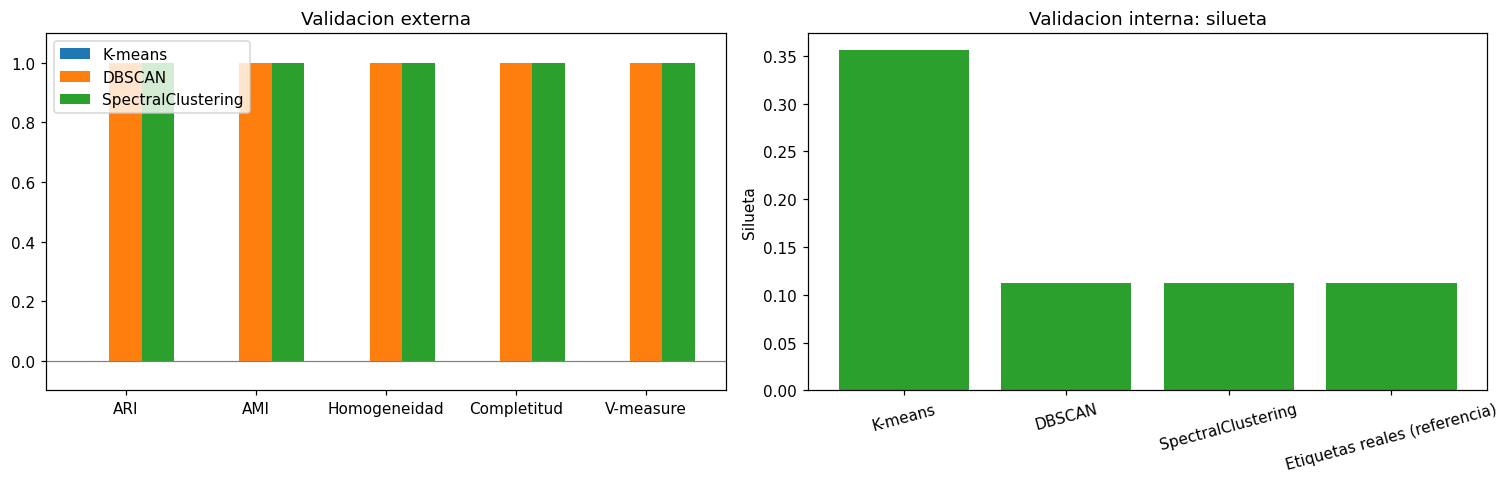

In [21]:
modelos = list(resultados.keys())
externas_graf = ["ARI", "AMI", "Homogeneidad", "Completitud", "V-measure"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Externas
ancho = 0.25
posiciones = np.arange(len(externas_graf))
for i, modelo in enumerate(modelos):
    valores = tabla.loc[modelo, externas_graf].values.astype(float)
    axes[0].bar(posiciones + i * ancho, valores, width=ancho, label=modelo)
axes[0].set_xticks(posiciones + ancho)
axes[0].set_xticklabels(externas_graf)
axes[0].set_ylim(-0.1, 1.1)
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_title("Validacion externa")
axes[0].legend()

# Silueta (interna), incluyendo la referencia
nombres_sil = list(tabla.index)
axes[1].bar(nombres_sil, tabla["Silueta"].values.astype(float), color="tab:green")
axes[1].set_title("Validacion interna: silueta")
axes[1].set_ylabel("Silueta")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 6. Analisis e interpretacion

**Resultados de la ejecucion de referencia** (con `random_state=42`; puede haber diferencias minimas segun la version de scikit-learn):

| Modelo | ARI | Homogeneidad | Completitud | Silueta | Calinski-Harabasz | Davies-Bouldin |
|---|---|---|---|---|---|---|
| K-means | -0.001 | 0.00 | 0.00 | 0.356 | 578.7 | 1.18 |
| DBSCAN | 1.000 | 1.00 | 1.00 | 0.113 | 0.001 | 892.1 |
| SpectralClustering | 1.000 | 1.00 | 1.00 | 0.113 | 0.001 | 892.1 |
| Etiquetas reales | 1.000 | 1.00 | 1.00 | 0.113 | 0.001 | 892.1 |

**1. K-means no recupera la estructura.** Su ARI es practicamente 0 y su homogeneidad y completitud son 0: el agrupamiento es equivalente a asignar puntos al azar respecto de las clases reales. K-means minimiza la distancia de cada punto a su centroide, por lo que solo produce clusters convexos separados por fronteras lineales. Corta ambos circulos por la mitad, y cada cluster termina con una mitad del circulo externo y una mitad del interno.

**2. DBSCAN y SpectralClustering recuperan los dos circulos.** Todas las metricas externas valen 1 (la informacion mutua alcanza su maximo, ln 2 = 0.693). DBSCAN lo logra porque agrupa por conectividad de densidad, y SpectralClustering porque trabaja sobre un grafo de vecinos, donde cada circulo es un componente conectado. Ninguno de los dos asume clusters esfericos.

**3. Las metricas internas dan el orden inverso.** K-means obtiene la mejor silueta, el mejor Calinski-Harabasz y el mejor Davies-Bouldin, mientras que el agrupamiento correcto obtiene los peores valores. La razon es que estas metricas miden compacidad y separacion en terminos de distancias a centroides, es decir, premian clusters convexos. Los dos circulos concentricos comparten el mismo centro, asi que la dispersion entre clusters es casi nula (Calinski-Harabasz cercano a 0) y Davies-Bouldin se dispara. La fila de referencia con las etiquetas reales lo confirma: el agrupamiento perfecto puntua peor que uno incorrecto.

**4. Conclusiones practicas.**
- Las metricas internas solo son comparables entre algoritmos que comparten la misma nocion de cluster. Cuando la geometria es no convexa hay que apoyarse en la validacion externa (si existe una referencia) y en la inspeccion visual.
- DBSCAN no requiere fijar el numero de clusters, pero es sensible a `eps`. Con un valor menor, por ejemplo `eps=0.15`, fragmenta los circulos en varios clusters y aparecen puntos de ruido; conviene apoyarse en el grafico de k-distancias.
- SpectralClustering si requiere `n_clusters` y es notablemente mas lento que K-means y DBSCAN (construye un grafo y calcula su descomposicion espectral); K-means y DBSCAN tienen tiempos comparables en este dataset, pero K-means solo sirve cuando los grupos son aproximadamente esfericos.

**Experimentos sugeridos:** variar `noise` y `factor` en `make_circles`, probar otros valores de `eps` y `min_samples`, o usar `affinity="rbf"` en SpectralClustering y observar como cambian las metricas.